In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from workflow_utils import visualization
import matplotlib.pyplot as plt
from math import ceil
from workflow_utils import stats

In [2]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [3]:
data = sns.load_dataset('iris')

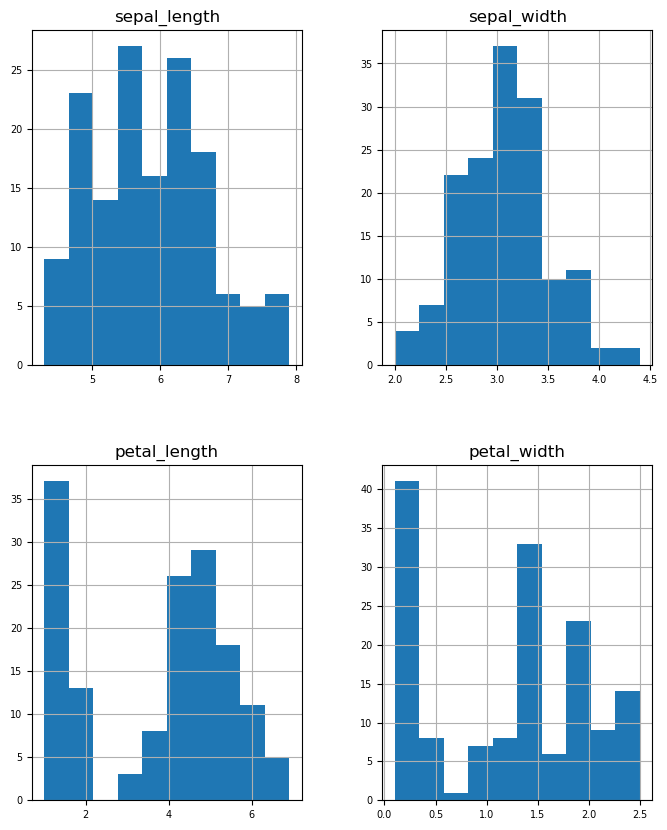

In [4]:
_ = visualization.histograms(data, size=(8,10), bins=10)

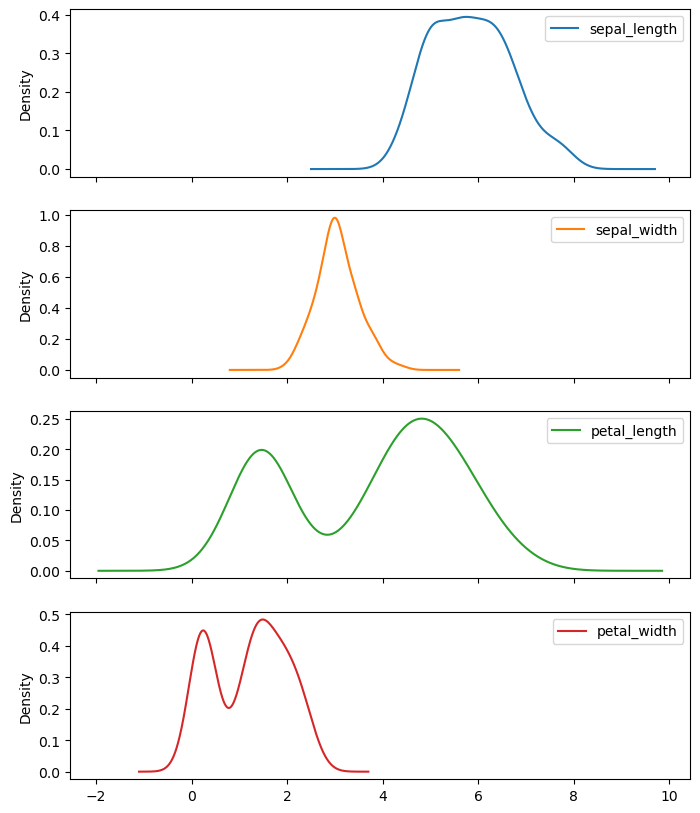

In [5]:
_ = visualization.kdes(data,  size=(8,10))

In [6]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


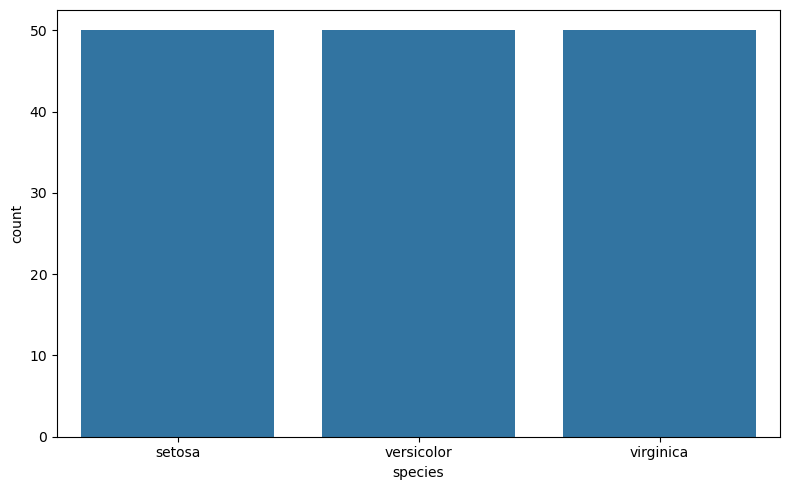

In [7]:
one_plot = visualization.countplots(data, size=(8,5))

In [8]:
data2 = data.copy()
data2["species2"] = data2["species"]

In [9]:
data3 = data2.copy()
data3["species3"] = data3["species"]

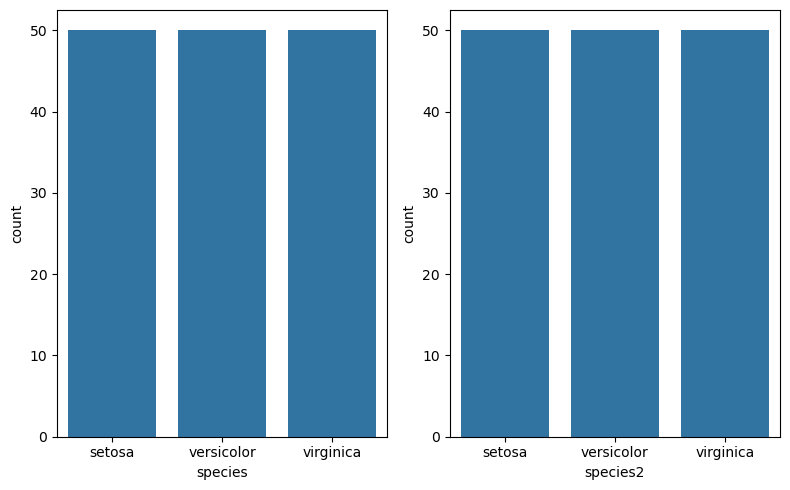

In [10]:
one_row_plot = one_col_plot = visualization.countplots(data2, size=(8,5))

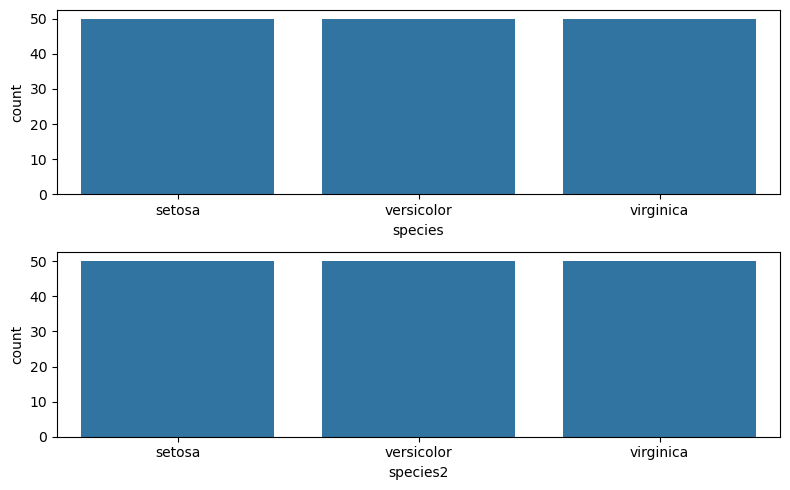

In [11]:
one_col_plot = visualization.countplots(data2, cols=1, size=(8,5))

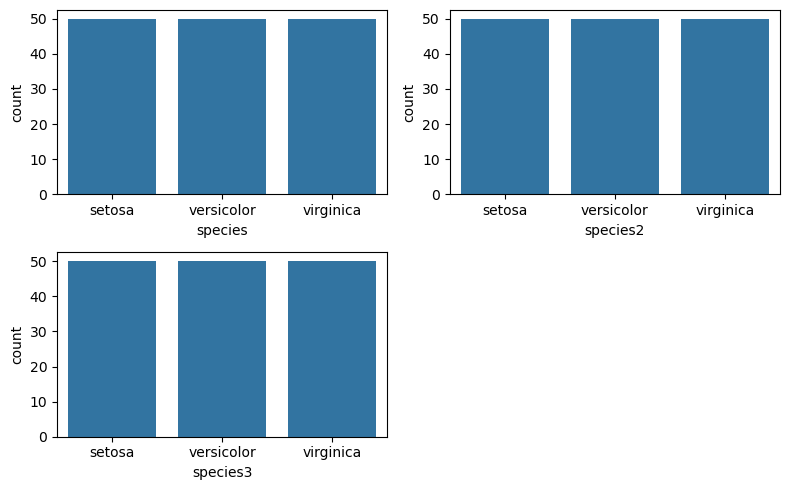

In [12]:
three_plot = visualization.countplots(data3, cols=2, size=(8,5))

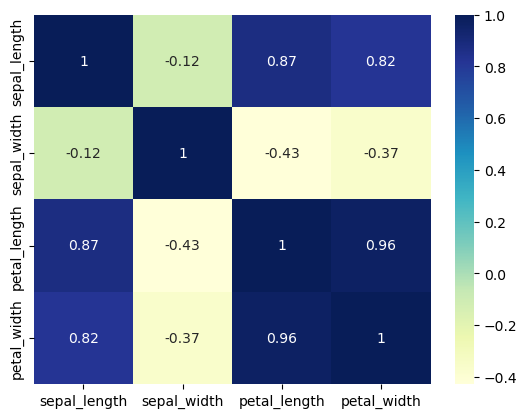

In [13]:
_ = visualization.correlation_heatmap(data)

In [14]:
example = data['sepal_length'][:10]

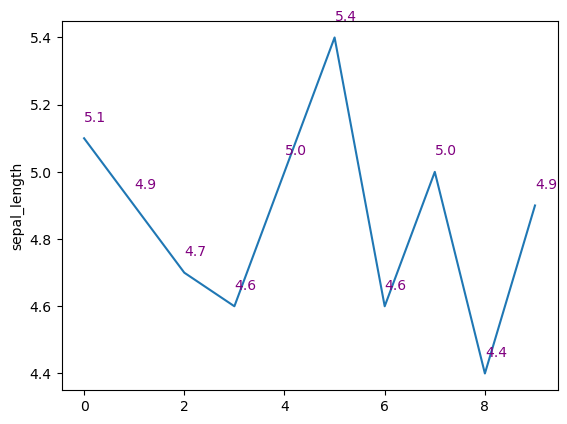

In [15]:
ax = visualization.labeled_lineplot(example, offset=-0.05)

In [16]:
vif = stats.vif(data, exclude=['species'])
vif

,feature,VIF
0,sepal_length,262.969
2,petal_length,172.961
1,sepal_width,96.353
3,petal_width,55.502


In [17]:
data['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [18]:
titanic = sns.load_dataset('titanic')

In [19]:
titanic["alive"] = titanic["alive"].map({"no": 0, "yes": 1})

In [20]:
titanic = titanic.dropna()

In [21]:
ks_result = stats.kstests(titanic, 'alive')
ks_result

,feature,statistic,pvalue
0,survived,1.000,0.000
1,pclass,0.044,1.000
2,age,0.273,0.004
3,sibsp,0.117,0.593
4,parch,0.045,1.000
5,fare,0.210,0.050


In [22]:
titanic.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive             int64
alone              bool
dtype: object

In [23]:
pearson_chi2 = stats.pearson_chi2(titanic, 'alive')
pearson_chi2

,feature,statistic,pvalue
0,sex,48.728,0.000
1,embarked,NaN,NaN
2,class,NaN,NaN
3,who,NaN,NaN
4,deck,NaN,NaN
5,embark_town,NaN,NaN


In [24]:
from scipy.stats import chi2_contingency

In [25]:
ct = pd.crosstab(titanic['class'], titanic['alive'])
ct

alive,0,1
class,,
First,51,106
Second,3,12
Third,5,5


In [26]:
res = chi2_contingency(ct)
res.expected_freq

array([[ 50.8956044 , 106.1043956 ],
       [  4.86263736,  10.13736264],
       [  3.24175824,   6.75824176]])